# Arrehnius

In [1]:
# --------------------------------------------------------
# External packages
import matplotlib.pyplot as plt
import jax.numpy as jnp
from tabulate import tabulate

# --------------------------------------------------------
# Internal modules
from diffPLOG2TROE import constants
from diffPLOG2TROE.kinetics import Arrhenius, ReparametrizedArrhenius

This tutorial demonstrates the computation of kinetic rate constants for a simple Arrhenius reaction across a specified temperature range. The implementation focuses solely on the forward reaction rate constant, as determined by user-provided parameters. Note that this code does not incorporate chemical equilibrium calculations, thus considering only unidirectional reaction kinetics.
- Equation
    > $k_f(T) = A \: T^n \: exp\left(-\frac{Eact}{RT}\right)$
- CHEMKIN representation
    >```
    >H2 + O = H + OH    +5.080E+04 +2.670E+00 +6.292E+03
    >```
- Representing the rate constant as a python object (keep in mind that the name is optional and can be omitted), passing directly a dictionary of parameters to the Arrhenius object and construct the rate object, underneet the library performs also some checks on the physical consistency of the values.
     
    >```python
    >reaction = Arrhenius(name="H2+O=H+OH", parameters={"A": 5.080e+04, "n": 2.670E+00, "Ea": 6.292e+03})
    >```

In [2]:
# --------------------------------------------------------
# Direct parameters initialization
reaction = Arrhenius(name="H2+O=H+OH", parameters={"A": 5.080e+04, "n": 2.670E+00, "Ea": 6.292e+03})

## Rate constant computation

After initializing the rate constant correctly, we gain access to the methods specific to the Arrhenius object, including the calculation of the kinetic constant across different temperature ranges. Keep in mind that the standard or modified arrhenius expression express the kinetic constant only as a temperature dependent function.

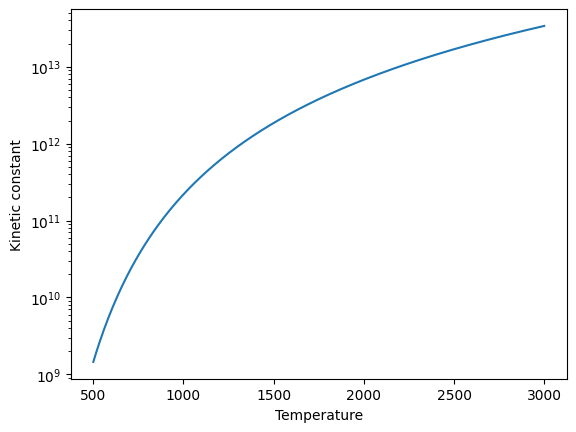

In [3]:
# --------------------------------------------------------
# Compute the rate constant
T_range = jnp.linspace(500, 3000, 300)
kinetic_constant = reaction.rate_constant(T_range)

# --------------------------------------------------------
# Let's visualize it
plt.semilogy(T_range, kinetic_constant)
plt.xlabel("Temperature")
plt.ylabel("Kinetic constant")
plt.show()

## Reparametrized (Centered) Arrhenius

The reparametrized Arrhenius equation addresses numerical and statistical issues that can arise when fitting experimental data to the standard Arrhenius form. By introducing a reference temperature, this approach provides better parameter estimation and reduced correlation between fitted parameters.

### Mathematical Formulation

- **Standard Arrhenius equation**
    > $k_f(T) = A \: T^n \: exp\left(-\frac{E_a}{RT}\right)$

- **Reparametrized (Centered) Arrhenius equation**
    > $k_f(T) = k_{ref} \: \left(\frac{T}{T_{ref}}\right)^n \: exp\left(-\frac{E_a}{R}\left(\frac{1}{T} - \frac{1}{T_{ref}}\right)\right)$

Where:
- $k_{ref}$ is the rate constant at the reference temperature $T_{ref}$
- $T_{ref}$ is a user-chosen reference temperature (typically near the center of experimental range)
- $n$ and $E_a$ retain the same physical meaning as in the standard form

### Key Advantages

1. **Reduced Parameter Correlation**: In the standard form, the pre-exponential factor $A$ and activation energy $E_a$ are often highly correlated during fitting, leading to:
   - Large parameter uncertainties
   - Numerical instability in optimization
   - Poor extrapolation beyond experimental range

2. **Improved Numerical Conditioning**: The centered form provides better numerical properties for:
   - Least-squares fitting algorithms
   - Parameter uncertainty estimation
   - Convergence in optimization routines

### Implementation in Python

Creating a reparametrized Arrhenius object requires specifying the reference temperature and rate constant at that temperature:

>```python
>reaction = ReparametrizedArrhenius(
>    parameters={
>        "k_ref": 2.5e8,    # Rate constant at T_ref [units depend on reaction order]
>        "n": 0.27,         # Temperature exponent [dimensionless]
>        "Ea": 38300,       # Activation energy [cal/mol]
>        "T_ref": 1000.0    # Reference temperature [K]
>    },
>    name="H2+O=H+OH_centered"
>)
>```

### Conversion Between Forms

The library provides seamless conversion between standard and reparametrized forms:

- **From reparametrized to standard**: `reaction.to_standard_form()`
- **From standard to reparametrized**: `ReparametrizedArrhenius.from_standard_form(params, T_ref)`

Both forms are mathematically equivalent and will produce identical rate constants at any temperature.

In [4]:
# --------------------------------------------------------
# Reparametrized (Centered) Arrhenius Example
# --------------------------------------------------------
# Choose a reference temperature (typically middle of experimental range)
T_ref = 1000.0

# Define parameters for the centered form
k_ref = 2.5e8   # Rate constant at T_ref [cm3/(mol s)]
n = 0.27        # Temperature exponent (same as standard form)
Ea = 38300      # Activation energy [cal/mol] (same as standard form)

# Create reparametrized Arrhenius object
reparametrized_reaction = ReparametrizedArrhenius(
    name="H2+O=H+OH_centered",
    parameters={"k_ref": k_ref, "n": n, "Ea": Ea, "T_ref": T_ref}
)

# --------------------------------------------------------
# Convert between standard and reparametrized forms
# --------------------------------------------------------
# Convert reparametrized to standard form
standard_params = reparametrized_reaction.to_standard_form()
print(f"Equivalent standard Arrhenius parameters:")
print(f" - A  = {standard_params['A']:.2e}")
print(f" - n  = {standard_params['n']:.3f}")
print(f" - Ea = {standard_params['Ea']:.0f} cal/mol")

# --------------------------------------------------------
# Create standard Arrhenius from the converted parameters
# This can be handy in the case the user wants to implement
# its own strategies
standard_reaction_converted = Arrhenius(standard_params, name="H2+O=H+OH_standard")
# --------------------------------------------------------
# Convert standard to reparametrized form with a different
# reference temperature
T_ref_new = 1200.0  # Different reference temperature
reparametrized_from_standard = ReparametrizedArrhenius.from_standard_form(
    name="H2+O=H+OH_from_standard",
    parameters=standard_params,
    T_ref=T_ref_new,
)

print(f"\nConverted back to reparametrized form (T_ref = {T_ref_new} K):")
print(f" - k_ref = {jnp.exp(reparametrized_from_standard.lnk_ref):.2e}")
print(f" - n     = {reparametrized_from_standard.n:.3f}")
print(f" - Ea    = {reparametrized_from_standard.EaR * constants.R_cal_mol:.0f} cal/mol\n")

# --------------------------------------------------------
# Compare rate constants from both forms
T_test = jnp.linspace(300, 3000, 10)
k_reparametrized = reparametrized_reaction.rate_constant(T_test)
k_standard = standard_reaction_converted.rate_constant(T_test)

# --------------------------------------------------------
# Pretty printing the comparison
data = []
for i, T in enumerate(T_test):
    rel_error = abs(k_reparametrized[i] - k_standard[i]) / k_standard[i] * 100
    data.append([T, f"{k_reparametrized[i]:.4e}", f"{k_standard[i]:.4e}", f"{rel_error:.2e}%"])

headers = ["Temperature [K]", "Reparametrized\narrhenius", "Standard\narrhenius", "Relative Error (%)"]
print(
    tabulate(
        data,
        headers=headers,
        tablefmt="fancy_grid",
        colalign=("center", "center", "center", "center",),
        floatfmt=(".6e")
    )
)

Equivalent standard Arrhenius parameters:
 - A  = 9.08e+15
 - n  = 0.270
 - Ea = 38300 cal/mol

Converted back to reparametrized form (T_ref = 1200.0 K):
 - k_ref = 6.52e+09
 - n     = 0.270
 - Ea    = 38300 cal/mol

╒═══════════════════╤══════════════════╤══════════════╤══════════════════════╕
│  Temperature [K]  │  Reparametrized  │   Standard   │  Relative Error (%)  │
│                   │    arrhenius     │  arrhenius   │                      │
╞═══════════════════╪══════════════════╪══════════════╪══════════════════════╡
│   3.000000e+02    │   5.322100e-12   │ 5.322100e-12 │      1.43e-12%       │
├───────────────────┼──────────────────┼──────────────┼──────────────────────┤
│   6.000000e+02    │   5.725900e+02   │ 5.725900e+02 │      2.58e-13%       │
├───────────────────┼──────────────────┼──────────────┼──────────────────────┤
│   9.000000e+02    │   2.854700e+07   │ 2.854700e+07 │      7.18e-13%       │
├───────────────────┼──────────────────┼──────────────┼─────────────────